# Pairs trading with transaction costs

What is pairs trading? 

[Pairs trading](https://www.investopedia.com/terms/p/pairstrade.asp) is a market neutral trading strategy—it seeks to avoid some form of market risk entirely, typically by hedging—that involves taking simultaneously a long position with a short one in two highly correlated stocks or assets, this is crucial for the strategy, but finding and maintaining two assets that have a high correlation can be challenging.

> The strategy monitors performance of two historically correlated securities. When the correlation between the two securities temporarily weakens, i.e. one stock moves up while the other moves down, the pairs trade would be to short the outperforming stock and to long the underperforming one, betting that the "spread" between the two would eventually converge. [1]

The divergence within a pair can be caused by temporary supply/demand changes, large buy/sell orders for one security, reaction for important news about one of the companies, and so on.

> The reason for the deviated stock to come back to original value is itself an assumption. It is assumed that the pair will have similar business performance as in the past during the holding period of the stock.

**Potential drawbacks of the strategy:**

- The divergence between the prices of the securities can be a rational response to news related to one of the securities, invalidating the reversion to the mean assumption.
- Scarcity of opportunities
- Compete with HFT funds

Depending on the market sector, there exists multiple reasons for which two historically correlated securities can have differences on it's stock prices, e.g., company A's management could be extremely efficient while company B's management could be not efficient, this can cause stock A to rise and stock B to fall, and in this case it is not certain that stock B could go back to its mean since it's a management efficiency issue, hence shorting A and buying B would result in a potential loss. 

**Characteristics** 

- Pairs trading is a mean reverting strategy, betting that the prices will eventually return to historical trends, i.e., overperforming stock will do down to its historical mean and underperforming stock will go up to its historical mean

- Pairs trade can hedge sector and market risks, e.g., in case of a market crash, and the two positions going down with it, the trade would result in a gain on the short position and a loss on the long position, leaving a net profit close to breakeven.

**Potentially correlated pairs:**

- Coca Cola and Pepsi
- Walmart and Target
- Dell and HP
- Ford and General Motors

According to Skiena, highly-correlated pairs often (but not always) come from the same sector because they face similar systematic risks.

**Example:** 

> Pepsi (PEP) and Coca-Cola (KO) are different companies that create a similar product, soda pop. Historically, the two companies have shared similar dips and highs, depending on the soda pop market. If the price of Coca-Cola were to go up a significant amount while Pepsi stayed the same, a pairs trader would buy Pepsi stock and sell Coca-Cola stock, assuming that the two companies would later return to their historical balance point. If the price of Pepsi rose to close that gap in price, the trader would make money on the Pepsi stock, while if the price of Coca-Cola fell, they would make money on having shorted the Coca-Cola stock. [2]

## References
<a id="1">[1]</a> 
Skiena, S. 
[Lecture on pairs trading](https://www3.cs.stonybrook.edu/~skiena/691/lectures/lecture23.pdf)

<a id="2">[2]</a> 
Wikipedia. [Pair trading](https://en.wikipedia.org/wiki/Pairs_trade)




In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.autograd import grad
import torch.optim as optim
import math
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

In [ ]:
torch.set_default_dtype(torch.float64)

# Model parameters
param = {
    # Initial condition
    'p0': 1,
    "mu": 0.2,
    "sigma": 0.4,
    "theta": 0.1,
    "kappa": 1.0,
    "nu": 0.15,
    "rho": 0.5,
    "r": 0.01,
    "gamma": 5.0,
    # Transaction cost params
    "ap": 1.0005,  # ap = 1 + zeta_p
    "bp": 0.9995,  # bp = 1 - eta_p
    "aq": 1.0005,  # aq = 1 + zeta_q
    "bq": 0.9995,  # bq = 1 - eta_q
    # Domain
    "T": 1.0
}

# A_minus and A_plus
def A_minus(p, x):
    # A- = (a_p - b_q * exp(x)) * p
    return (param["ap"] - param["bq"] * torch.exp(x)) * p

def A_plus(p, x):
    # A+ = (b_p - a_q * exp(x)) * p
    return (param["bp"] - param["aq"] * torch.exp(x)) * p

# Terminal payoff, i.e., liquidated value of the portfolio
# J(p(T), x(T), y(T)) = A+ * y 1{y>=0} + A- * y 1{y<0}
def terminal_J(p, x, y):
    return torch.where(y >= 0, A_plus(p, x) * y, A_minus(p, x) * y)

# Neural network for H(t, p, x, y)
class Net(nn.Module):
    def __init__(self, n_in, n_out=1, layers=[64, 64, 64]):
        super().__init__()
        seq = [nn.Linear(n_in, layers[0]), nn.Tanh()]
        for i in range(len(layers)-1):
            seq += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        seq.append(nn.Linear(layers[-1], n_out))
        self.net = nn.Sequential(*seq)
    def forward(self, *args):
        x = torch.cat([a if a.ndim > 1 else a.unsqueeze(1) for a in args], dim=1)
        return self.net(x).squeeze(-1)

net_u  = Net(4).to(device)          # u = log H(t,p,x,y)
yb = Net(3).to(device)          # buy boundary Y_b(t,p,x)
ys = Net(3).to(device)          # sell boundary Y_s(t,p,x)

# Domain bounds
t_min, t_max = 0.0, param['T']
p_min, p_max = 0.3, 4.0
x_min, x_max = -0.5, 0.5
y_min, y_max = -20, 20

# Sample function for t, p, x
def sample_tpx(batch_size):
    t = torch.rand(batch_size, device=device) * (t_max - t_min) + t_min
    p = torch.rand(batch_size, device=device) * (p_max - p_min) + p_min
    x = torch.rand(batch_size, device=device) * (x_max - x_min) + x_min
    t.requires_grad = True
    p.requires_grad = True
    x.requires_grad = True
    return t, p, x

# PDE residual for u = log H (transformed L_{2,o} H = 0)
def pde_residual(u, t, p, x, y):
    grads = torch.autograd.grad(u, (t, p, x, y), 
                               grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)
    du_t, du_p, du_x = grads[0], grads[1], grads[2]

    # Second derivatives
    du_pp = torch.autograd.grad(du_p, p, torch.ones_like(du_p), create_graph=True)[0]
    du_xx = torch.autograd.grad(du_x, x, torch.ones_like(du_x), create_graph=True)[0]
    du_px = torch.autograd.grad(du_p, x, torch.ones_like(du_p), create_graph=True)[0]

    res = (du_t
            + param["kappa"]*(param["theta"] - x)*du_x
            + param["mu"]*p*du_p
            + 0.5*param["nu"]**2 * (du_xx + du_x**2)
            + param["rho"]*param["nu"]*param["sigma"]*p * (du_px + du_p*du_x)
            + 0.5*(param["sigma"]*p)**2 * (du_pp + du_p**2))
    return res

# 2. Loss weights
w_pde   = 1.0
w_buy   = 5      
w_sell  = 5      
w_bc    = 5
w_term  = 5
w_order = 10      # ← penalty for Yb > Ys

# Loss function
def compute_loss(n_batch=2000, delta_out=4.0):
    # Common points
    t, p, x = sample_tpx(n_batch)
    yb = yb(t, p, x)
    ys = ys(t, p, x)
    loss_order = torch.mean(torch.clamp(yb - ys, min=0.0)**2)

    # No-transaction region (interior)
    mask = yb < ys
    if mask.any():
        t_i, p_i, x_i, yb_i, ys_i = t[mask], p[mask], x[mask], yb[mask], ys[mask]
        # Fresh leaf variable for y
        xi = torch.rand_like(yb_i)
        y_i = yb_i + xi * (ys_i - yb_i)
        y_i.requires_grad_(True)                   
        u_i = net_u(t_i, p_i, x_i, y_i)
        loss_pde = torch.mean(pde_residual(u_i, t_i, p_i, x_i, y_i)**2)
    else:
        loss_pde = torch.tensor(0.0, device=device)

    # Buy region
    y_buy = yb - torch.rand_like(yb) * delta_out
    y_buy.requires_grad_(True)
    u_buy = net_u(t, p, x, y_buy)   # u(t,p,x,y)  where y = log H at a point inside buy region
    u_b   = net_u(t, p, x, yb)      # u(t,p,x,Y_b) = log H on the buy boundary
    target_buy = u_b - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x) * (y_buy - yb)
    loss_buy = torch.mean((u_buy - target_buy)**2)

    # Sell region
    y_sell = ys + torch.rand_like(ys) * delta_out
    y_sell.requires_grad_(True)
    u_sell = net_u(t, p, x, y_sell)
    u_s   = net_u(t, p, x, ys)
    target_sell = u_s - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x) * (y_sell - ys)
    loss_sell = torch.mean((u_sell - target_sell)**2)

    # Boundary conditions (smooth pasting)
    # buy boundary
    yb_b = yb(t, p, x)
    yb_b.requires_grad_(True)
    uy_b = torch.autograd.grad(net_u(t, p, x, yb_b), yb_b,
                              torch.ones_like(yb_b), create_graph=True)[0]
    loss_bc_buy = torch.mean((uy_b + param["gamma"] *
                             torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x))**2)

    # sell boundary
    ys_s = ys(t, p, x)
    ys_s.requires_grad_(True)
    uy_s = torch.autograd.grad(net_u(t, p, x, ys_s), ys_s,
                              torch.ones_like(ys_s), create_graph=True)[0]
    loss_bc_sell = torch.mean((uy_s + param["gamma"] *
                              torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x))**2)

    # Terminal condition
    y_term = torch.rand(n_batch, device=device) * (y_max - y_min) + y_min
    t_term = torch.full((n_batch,), param["T"], device=device)
    p_term, x_term = sample_tpx(n_batch)[1], sample_tpx(n_batch)[2]
    u_term = net_u(t_term, p_term, x_term, y_term)
    loss_term = torch.mean((u_term + param["gamma"] * terminal_J(p_term, x_term, y_term))**2)

    total = (w_pde  * loss_pde +
             w_buy * loss_buy +
             w_sell * loss_sell +
             w_bc * loss_bc_buy +
             w_bc * loss_bc_sell +
             w_term * loss_term +
             w_order * loss_order)
    
    return total


optimizer = torch.optim.Adam(list(net_u.parameters()) +
                            list(yb.parameters()) +
                            list(ys.parameters()), lr=1e-3)

# scheduler = CosineAnnealingWarmRestarts(
#     optimizer, 
#     T_0=5000,      # First cycle length (epochs)
#     T_mult=2,      # Each restart doubles the cycle length
#     eta_min=1e-5   # Minimum LR (prevents stalling)
# )

# Training loop
training_params = {'epochs': 40000,
                   'n_batch': 5000}

for epoch in range(training_params["epochs"]):
    optimizer.zero_grad()
    loss = compute_loss(n_batch=training_params["n_batch"])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(net_u.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(yb.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(ys.parameters(), max_norm=1.0)

    optimizer.step()
    #scheduler.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d}  loss = {loss.item():.3e}")

print("Training finished!")

# 2

In [11]:
import torch
import torch.nn as nn
import numpy as np
from torch.autograd import grad
import torch.optim as optim
import math
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(torch.float64)

# Model parameters
param = {
    # Initial condition
    'p0': 1,
    "mu": 0.2,
    "sigma": 0.4,
    "theta": 0.1,
    "kappa": 1.0,
    "nu": 0.15,
    "rho": 0.5,
    "r": 0.01,
    "gamma": 5.0,
    # Transaction cost params
    "ap": 1.0005,  # ap = 1 + zeta_p
    "bp": 0.9995,  # bp = 1 - eta_p
    "aq": 1.0005,  # aq = 1 + zeta_q
    "bq": 0.9995,  # bq = 1 - eta_q
    # Domain
    "T": 1.0
}

# A_minus and A_plus
def A_minus(p, x):
    # A- = (a_p - b_q * exp(x)) * p
    return (param["ap"] - param["bq"] * torch.exp(x)) * p

def A_plus(p, x):
    # A+ = (b_p - a_q * exp(x)) * p
    return (param["bp"] - param["aq"] * torch.exp(x)) * p

# Terminal payoff, i.e., liquidated value of the portfolio
# J(p(T), x(T), y(T)) = A+ * y 1{y>=0} + A- * y 1{y<0}
def terminal_J(p, x, y):
    return torch.where(y >= 0, A_plus(p, x) * y, A_minus(p, x) * y)

# Neural network for u(t,p,x,y) = log H(t, p, x, y)
class Net(nn.Module):
    def __init__(self, n_in, n_out=1, layers=[64, 64, 64]):
        super().__init__()
        seq = [nn.Linear(n_in, layers[0]), nn.Tanh()]
        for i in range(len(layers)-1):
            seq += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        seq.append(nn.Linear(layers[-1], n_out))
        self.net = nn.Sequential(*seq)
    def forward(self, *args):
        x = torch.cat([a if a.ndim > 1 else a.unsqueeze(1) for a in args], dim=1)
        return self.net(x).squeeze(-1)
    
class BoundaryNet(nn.Module):         # SINGLE network → (center, width) → (Yb, Ys)
    def __init__(self):
        super().__init__()
        self.center = nn.Sequential(
            nn.Linear(3, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 1)
        )
        self.width = nn.Sequential(      # Forces positive width → Yb < Ys always
            nn.Linear(3, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 1),
            nn.Softplus()
        )
        
    def forward(self, t, p, x):
        inp = torch.cat([t.unsqueeze(1), p.unsqueeze(1), x.unsqueeze(1)], dim=1)
        center = self.center(inp).squeeze(-1)
        width  = self.width(inp).squeeze(-1) + 0.5   # minimum width 0.5 → prevents collapse
        return center - width/2, center + width/2   # Yb, Ys


net_u  = Net(4).to(device)          # u = log H(t,p,x,y)
net_bound = BoundaryNet().to(device)

# Domain bounds
t_min, t_max = 0.0, param['T']
p_min, p_max = 0.3, 4.0
x_min, x_max = -0.5, 0.5
y_min, y_max = -15, 15

# Sample function for t, p, x
def sample_tpx(batch_size):
    t = torch.rand(batch_size, device=device) * (t_max - t_min) + t_min
    p = torch.rand(batch_size, device=device) * (p_max - p_min) + p_min
    x = torch.rand(batch_size, device=device) * (x_max - x_min) + x_min
    t.requires_grad = True
    p.requires_grad = True
    x.requires_grad = True
    return t, p, x

# PDE residual for u = log H (transformed L_{2,o} H = 0)
def pde_residual(u, t, p, x, y):
    grads = torch.autograd.grad(u, (t, p, x, y), 
                               grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)
    du_t, du_p, du_x = grads[0], grads[1], grads[2]

    # Second derivatives
    du_pp = torch.autograd.grad(du_p, p, torch.ones_like(du_p), create_graph=True)[0]
    du_xx = torch.autograd.grad(du_x, x, torch.ones_like(du_x), create_graph=True)[0]
    du_px = torch.autograd.grad(du_p, x, torch.ones_like(du_p), create_graph=True)[0]

    res = (du_t
            + param["kappa"]*(param["theta"] - x)*du_x
            + param["mu"]*p*du_p
            + 0.5*param["nu"]**2 * (du_xx + du_x**2)
            + param["rho"]*param["nu"]*param["sigma"]*p * (du_px + du_p*du_x)
            + 0.5*(param["sigma"]*p)**2 * (du_pp + du_p**2))
    return res

# 2. Loss weights
w_pde   = 1.0
w_buy   = 5      
w_sell  = 5      
w_bc    = 5
w_term  = 5

# Loss function
def compute_loss(n_batch=2000, delta_out=4.0):
    # Common points
    t, p, x = sample_tpx(n_batch)
    yb, ys = net_bound(t, p, x)

    # No-transaction region (interior)
    mask = yb < ys
    if mask.any():
        t_i, p_i, x_i, yb_i, ys_i = t[mask], p[mask], x[mask], yb[mask], ys[mask]
        # Fresh leaf variable for y
        xi = torch.rand_like(yb_i)
        y_i = yb_i + xi * (ys_i - yb_i)
        y_i.requires_grad_(True)                   
        u_i = net_u(t_i, p_i, x_i, y_i)
        loss_pde = torch.mean(pde_residual(u_i, t_i, p_i, x_i, y_i)**2)
    else:
        loss_pde = torch.tensor(0.0, device=device)

    # Buy region
    y_buy = yb - torch.rand_like(yb) * delta_out
    y_buy.requires_grad_(True)
    u_buy = net_u(t, p, x, y_buy)   # u(t,p,x,y)  where y = log H at a point inside buy region
    u_b   = net_u(t, p, x, yb)      # u(t,p,x,Y_b) = log H on the buy boundary
    target_buy = u_b - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x) * (y_buy - yb)
    loss_buy = torch.mean((u_buy - target_buy)**2)

    # Sell region
    y_sell = ys + torch.rand_like(ys) * delta_out
    y_sell.requires_grad_(True)
    u_sell = net_u(t, p, x, y_sell)
    u_s   = net_u(t, p, x, ys)
    target_sell = u_s - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x) * (y_sell - ys)
    loss_sell = torch.mean((u_sell - target_sell)**2)

    # Boundary conditions (smooth pasting)
    # buy boundary
    yb_bc = yb.clone().detach().requires_grad_(True)
    ys_bc = ys.clone().detach().requires_grad_(True)
    grad_b = torch.autograd.grad(net_u(t,p,x,yb_bc), yb_bc, torch.ones_like(yb_bc), create_graph=True)[0]
    grad_s = torch.autograd.grad(net_u(t,p,x,ys_bc), ys_bc, torch.ones_like(ys_bc), create_graph=True)[0]
    loss_sp = torch.mean((grad_b + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_minus(p,x))**2) + \
              torch.mean((grad_s + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_plus(p,x))**2)


    # Terminal condition
    y_term = torch.rand(n_batch, device=device) * (y_max - y_min) + y_min
    t_term = torch.full((n_batch,), param["T"], device=device)
    p_term, x_term = sample_tpx(n_batch)[1], sample_tpx(n_batch)[2]
    u_term = net_u(t_term, p_term, x_term, y_term)
    loss_term = torch.mean((u_term + param["gamma"] * terminal_J(p_term, x_term, y_term))**2)

    total = (w_pde  * loss_pde +
             w_buy * loss_buy +
             w_sell * loss_sell +
             w_bc * loss_sp +
             w_term * loss_term)
    
    return total


optimizer = torch.optim.Adam(list(net_u.parameters()) +
                            list(net_bound.parameters()), lr=8e-4)

# scheduler = CosineAnnealingWarmRestarts(
#     optimizer, 
#     T_0=5000,      # First cycle length (epochs)
#     T_mult=2,      # Each restart doubles the cycle length
#     eta_min=1e-5   # Minimum LR (prevents stalling)
# )

# Training loop
training_params = {'epochs': 40000,
                   'n_batch': 10000}

for epoch in range(training_params["epochs"]):
    optimizer.zero_grad()
    loss = compute_loss(n_batch=training_params["n_batch"])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(list(net_u.parameters()) + list(net_bound.parameters()), 1.0)

    optimizer.step()
    #scheduler.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d}  loss = {loss.item():.3e}")

print("Training finished!")

Epoch     0  loss = 5.773e+03


KeyboardInterrupt: 

In [6]:
import matplotlib.pyplot as plt

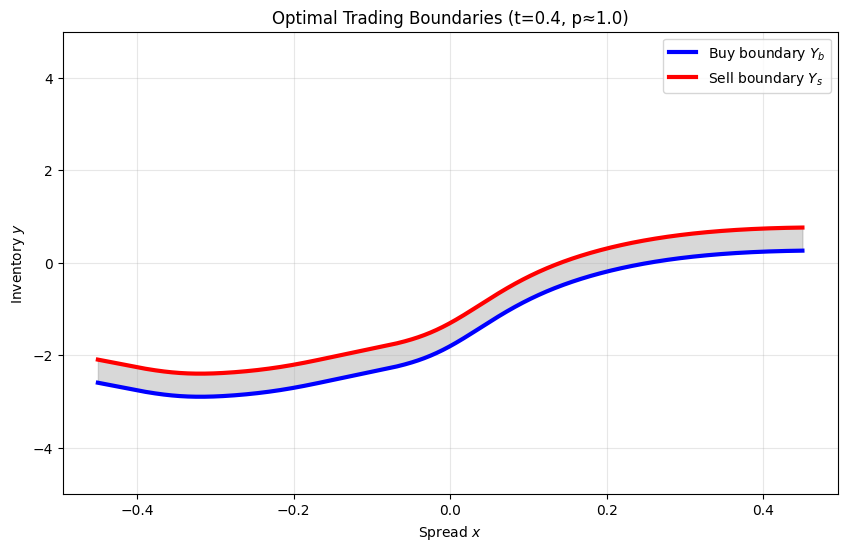

In [8]:
t_plot = torch.full((800,), 0.4, device=device)
p_plot = torch.full((800,), 1.0, device=device)
x_plot = torch.linspace(-0.45, 0.45, 800, device=device)

with torch.no_grad():
    yb_plot, ys_plot = net_bound(t_plot, p_plot, x_plot)

plt.figure(figsize=(10,6))
plt.plot(x_plot.cpu().numpy(), yb_plot.cpu().numpy(), 'b-', lw=3, label='Buy boundary $Y_b$')
plt.plot(x_plot.cpu().numpy(), ys_plot.cpu().numpy(), 'r-', lw=3, label='Sell boundary $Y_s$')
plt.fill_between(x_plot.cpu().numpy(), yb_plot.cpu().numpy(), ys_plot.cpu().numpy(), alpha=0.3, color='gray')
plt.xlabel('Spread $x$'); plt.ylabel('Inventory $y$')
plt.title('Optimal Trading Boundaries (t=0.4, p≈1.0)')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(-5,5); plt.show()

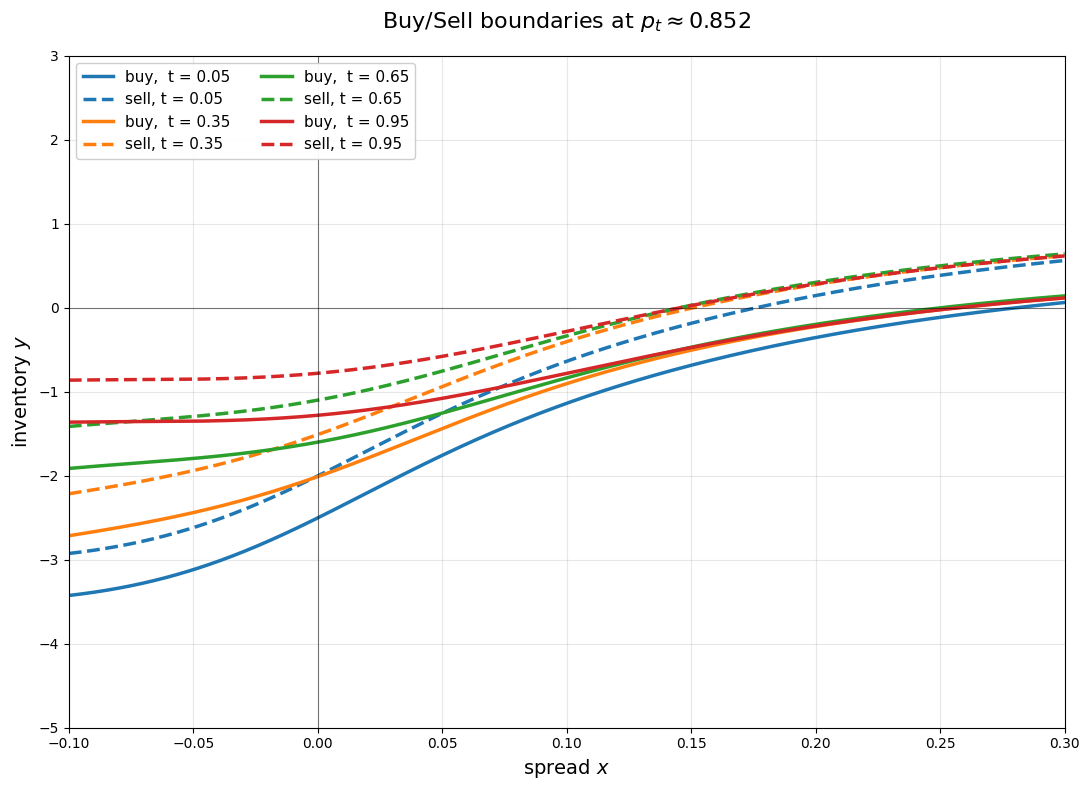

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# === SETTINGS ===
p_fixed = 0.852          # As in Xing's Figure 1
x_grid = torch.linspace(-0.10, 0.30, 1000, device=device)  # Focus on relevant spread range
times = [0.05, 0.35, 0.65, 0.95]   # Same as in the paper
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Classic matplotlib colors
labels = [f't = {t:.2f}' for t in times]

plt.figure(figsize=(11, 8))

with torch.no_grad():
    for i, t_val in enumerate(times):
        t_tensor = torch.full_like(x_grid, t_val)
        p_tensor = torch.full_like(x_grid, p_fixed)
        
        yb, ys = net_bound(t_tensor, p_tensor, x_grid)
        
        yb_np = yb.cpu().numpy()
        ys_np = ys.cpu().numpy()
        x_np  = x_grid.cpu().numpy()
        
        color = colors[i]
        
        # Buy boundary (lower)
        plt.plot(x_np, yb_np, color=color, linewidth=2.5, 
                 label=f'buy, {labels[i]}')
        
        # Sell boundary (upper)
        plt.plot(x_np, ys_np, color=color, linestyle='--', linewidth=2.5,
                 label=f'sell, {labels[i]}')

# === FINAL POLISH — exactly like Xing's figure ===
plt.xlabel('spread $x$', fontsize=14)
plt.ylabel('inventory $y$', fontsize=14)
plt.title(f'Buy/Sell boundaries at $p_t \\approx {p_fixed:.3f}$', fontsize=16, pad=20)

plt.xlim(-0.10, 0.30)
plt.ylim(-5, 3)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)

# Custom legend: one entry per time, with solid + dashed
handles, legend_labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(legend_labels, handles))  # remove duplicates
sorted_items = sorted(by_label.items(), key=lambda x: float(x[0].split('=')[-1]))

# Reorder legend: buy then sell for each time
ordered_handles = []
ordered_labels  = []
for t in times:
    t_str = f't = {t:.2f}'
    ordered_labels.append(f'buy,  {t_str}')
    ordered_labels.append(f'sell, {t_str}')
    ordered_handles.append(by_label[f'buy, {t_str}'])
    ordered_handles.append(by_label[f'sell, {t_str}'])

plt.legend(ordered_handles, ordered_labels, 
           ncol=2, fontsize=11, loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# === Settings ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
yb.eval()
ys.eval()

# Fixed price level (you said p ≈ 0.852)
p_fixed = 0.852

# Choose several times (from early to near maturity)
times = [0.05, 0.35, 0.65, 0.95]  # t = 0.05, 0.35, 0.65, 0.95
colors = ['blue', 'orange', 'green', 'red']
linestyles_buy = ['-', '-', '-', '-']
linestyles_sell = ['--', '--', '--', '--']

# Spread x grid
x_grid = np.linspace(-0.10, 0.30, 400)
X = torch.tensor(x_grid, dtype=torch.float64, device=device)
P = torch.full_like(X, p_fixed)

plt.figure(figsize=(10, 7))

for i, t_val in enumerate(times):
    T = torch.full_like(X, t_val)
    
    with torch.no_grad():
        yb = yb(T, P, X).cpu().numpy()
        ys = ys(T, P, X).cpu().numpy()
    
    label_buy = f'buy, t={t_val:.2f}' if i == 0 else f't={t_val:.2f}'
    label_sell = f'sell, t={t_val:.2f}'
    
    plt.plot(x_grid, yb, color=colors[i], linestyle='-', linewidth=2.5, label=label_buy)
    plt.plot(x_grid, ys, color=colors[i], linestyle='--', linewidth=2.5, label=label_sell)

plt.xlabel('Spread $x$', fontsize=14)
plt.ylabel('Inventory $y$', fontsize=14)
plt.title(f'Buy/Sell Boundaries at $p_t \\approx {p_fixed:.3f}$', fontsize=16)
plt.legend(fontsize=12, ncol=2)
plt.grid(True, alpha=0.3)
plt.xlim(-0.1, 0.30)
plt.ylim(-16, 16)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

# --- 1. PARAMETERS & HELPER FUNCTIONS ---
param = {
    "mu": 0.2, "sigma": 0.4, "theta": 0.1, "kappa": 1.0, "nu": 0.15,
    "rho": 0.5, "r": 0.01, "gamma": 5.0,
    "ap": 1.0005, "bp": 0.9995, "aq": 1.0005, "bq": 0.9995,
    "T": 1.0
}

# Normalization constants (CRITICAL for convergence)
norm_stats = {
    't_mean': 0.5, 't_std': 0.5,
    'p_mean': 2.15, 'p_std': 1.0,
    'x_mean': 0.0, 'x_std': 0.3,
    'y_mean': 0.0, 'y_std': 10.0
}

def normalize(t, p, x, y):
    t_n = (t - norm_stats['t_mean']) / norm_stats['t_std']
    p_n = (p - norm_stats['p_mean']) / norm_stats['p_std']
    x_n = (x - norm_stats['x_mean']) / norm_stats['x_std']
    y_n = (y - norm_stats['y_mean']) / norm_stats['y_std']
    return t_n, p_n, x_n, y_n

def A_minus(p, x):
    return (param["ap"] - param["bq"] * torch.exp(x)) * p

def A_plus(p, x):
    return (param["bp"] - param["aq"] * torch.exp(x)) * p

def terminal_J(p, x, y):
    # Smooth approximation of the terminal payoff to help gradients
    return torch.where(y >= 0, A_plus(p, x) * y, A_minus(p, x) * y)

# --- 2. NETWORK ARCHITECTURE ---

class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: Normalized t, p, x, y
        self.net = nn.Sequential(
            nn.Linear(4, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    
    def forward(self, t, p, x, y):
        # Normalize inputs before passing to network
        tn, pn, xn, yn = normalize(t, p, x, y)
        inputs = torch.cat([tn, pn, xn, yn], dim=1)
        return self.net(inputs)

class BoundaryNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: Normalized t, p, x
        self.net_center = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1) # Outputs the center of the no-trade zone
        )
        self.net_width = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
            nn.Softplus() # Guarantees width > 0, so yb < ys always
        )
        
    def forward(self, t, p, x):
        tn, pn, xn, _ = normalize(t, p, x, torch.zeros_like(t))
        inputs = torch.cat([tn, pn, xn], dim=1)
        
        center = self.net_center(inputs)
        width = self.net_width(inputs) + 0.1 # Add epsilon to prevent collapse
        
        yb = center - width / 2.0
        ys = center + width / 2.0
        return yb, ys

net_u = ValueNet().to(device)
net_b = BoundaryNet().to(device)

# --- 3. LOSS COMPUTATION ---

def pde_residual(u, t, p, x):
    # Gradients
    grads = torch.autograd.grad(u, (t, p, x), grad_outputs=torch.ones_like(u), create_graph=True)[0]
    dt, dp, dx = grads[0], grads[1], grads[2] # Note: y is fixed for partials here
    
    dp_p = torch.autograd.grad(dp, p, torch.ones_like(dp), create_graph=True)[0]
    dx_x = torch.autograd.grad(dx, x, torch.ones_like(dx), create_graph=True)[0]
    dp_x = torch.autograd.grad(dp, x, torch.ones_like(dp), create_graph=True)[0]

    # HJB Operator
    res = (dt 
           + param["kappa"] * (param["theta"] - x) * dx
           + param["mu"] * p * dp
           + 0.5 * param["nu"]**2 * (dx_x + dx**2) # assuming u is log-transformed
           + param["rho"] * param["nu"] * param["sigma"] * p * (dp_x + dp * dx)
           + 0.5 * (param["sigma"] * p)**2 * (dp_p + dp**2))
    return res

def compute_loss(batch_size=2000):
    # 1. Sample uniformly from the Domain
    t = torch.rand(batch_size, 1, device=device, requires_grad=True) * param['T']
    p = torch.rand(batch_size, 1, device=device, requires_grad=True) * (4.0 - 0.3) + 0.3
    x = torch.rand(batch_size, 1, device=device, requires_grad=True) * (0.5 - -0.5) - 0.5
    y = torch.rand(batch_size, 1, device=device, requires_grad=True) * (20 - -20) - 20
    
    # 2. Predict Boundaries
    yb, ys = net_b(t, p, x)
    
    # 3. Create Masks
    with torch.no_grad():
        mask_buy = (y < yb)
        mask_sell = (y > ys)
        mask_nt = (~mask_buy) & (~mask_sell)
        
    # 4. Forward Pass (Full Batch)
    u = net_u(t, p, x, y)
    
    # --- A. PDE Loss (Corrected) ---
    # We calculate residuals for ALL points first to maintain the graph connection.
    # The overhead is small compared to the stability gain.
    pde_res_all = pde_residual(u, t, p, x)
    
    if mask_nt.any():
        # NOW we slice the residuals, not the inputs
        loss_pde = torch.mean(pde_res_all[mask_nt]**2)
    else:
        loss_pde = torch.tensor(0.0, device=device)

    # --- B. Region Losses (Linearity in Buy/Sell Regions) ---
    # Calculate gradient u_y for the full batch first
    uy = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    
    target_grad_buy = -param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x)
    target_grad_sell = -param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x)
    
    # Apply masks to the computed gradients
    loss_buy = torch.mean((uy[mask_buy] - target_grad_buy[mask_buy])**2) if mask_buy.any() else torch.tensor(0.0, device=device)
    loss_sell = torch.mean((uy[mask_sell] - target_grad_sell[mask_sell])**2) if mask_sell.any() else torch.tensor(0.0, device=device)

    # --- C. Smooth Pasting (Boundary Conditions) ---
    # Evaluate u specifically AT the boundaries
    ub_val = net_u(t, p, x, yb)
    us_val = net_u(t, p, x, ys)
    
    uy_b = torch.autograd.grad(ub_val, yb, torch.ones_like(ub_val), create_graph=True)[0]
    uy_s = torch.autograd.grad(us_val, ys, torch.ones_like(us_val), create_graph=True)[0]
    
    target_b = -param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x)
    target_s = -param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x)
    
    loss_bc = torch.mean((uy_b - target_b)**2) + torch.mean((uy_s - target_s)**2)

    # --- D. Terminal Condition ---
    t_T = torch.full_like(t, param['T'])
    u_T = net_u(t_T, p, x, y)
    J = terminal_J(p, x, y)
    loss_term = torch.mean((u_T - (-param["gamma"] * J))**2)

    return loss_pde + loss_buy + loss_sell + loss_bc + 10.0 * loss_term

# --- 4. TRAINING LOOP ---
optimizer = torch.optim.Adam(list(net_u.parameters()) + list(net_b.parameters()), lr=5e-4)

print("Starting training...")
for epoch in range(10001):
    optimizer.zero_grad()
    loss = compute_loss(batch_size=4096)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net_u.parameters(), 1.0)
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.5f}")

# Plotting results
t_test = torch.full((100, 1), 0.5, device=device) # t = 0.5
p_test = torch.full((100, 1), 1.0, device=device) # p = 1.0
x_test = torch.linspace(-0.5, 0.5, 100, device=device).unsqueeze(1)

with torch.no_grad():
    yb_pred, ys_pred = net_b(t_test, p_test, x_test)

plt.figure(figsize=(8,5))
plt.plot(x_test.cpu(), yb_pred.cpu(), 'g', label='Buy Boundary (Lower)')
plt.plot(x_test.cpu(), ys_pred.cpu(), 'r', label='Sell Boundary (Upper)')
plt.fill_between(x_test.cpu().flatten(), yb_pred.cpu().flatten(), ys_pred.cpu().flatten(), color='gray', alpha=0.3, label='No-Trade Zone')
plt.xlabel('Spread (x)')
plt.ylabel('Position (y)')
plt.title('Learned Transaction Regions')
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === PARAMETERS (exactly as in Xing 2019) ===
param = {
    "mu": 0.2, "sigma": 0.4, "theta": 0.0, "kappa": 1.0, "nu": 0.15, "rho": 0.5,
    "r": 0.01, "gamma": 5.0,
    "ap": 1.0005, "bp": 0.9995, "aq": 1.0005, "bq": 0.9995, "T": 1.0
}

def A_minus(p, x):  return (param["ap"] - param["bq"] * torch.exp(x)) * p
def A_plus(p, x):   return (param["bp"] - param["aq"] * torch.exp(x)) * p
def terminal_J(p, x, y):
    return torch.where(y >= 0, A_plus(p, x) * y, A_minus(p, x) * y)

# === NETWORKS ===
class Net(nn.Module):
    def __init__(self, n_in, layers=[64]*6):
        super().__init__()
        nets = [nn.Linear(n_in, layers[0]), nn.Tanh()]
        for i in range(len(layers)-1):
            nets += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        nets.append(nn.Linear(layers[-1], 1))
        self.net = nn.Sequential(*nets)
    def forward(self, *x):
        x = torch.cat([xi.unsqueeze(1) if xi.ndim==1 else xi for xi in x], dim=1)
        return self.net(x).squeeze(-1)

net_u  = Net(4).to(device)   # log H(t,p,x,y)
yb = Net(3).to(device)   # Y_b(t,p,x)
ys = Net(3).to(device)   # Y_s(t,p,x)

# === DOMAIN ===
y_min, y_max = -20.0, 20.0
def sample(n):
    t = torch.rand(n, device=device) * param["T"]
    p = torch.rand(n, device=device) * 3.7 + 0.3
    x = torch.rand(n, device=device) * 1.0 - 0.5
    y = torch.rand(n, device=device) * (y_max - y_min) + y_min
    return t, p, x, y

# === PDE RESIDUAL ===
def pde_res(t, p, x, y):
    y = y.clone().detach().requires_grad_(True)
    u = net_u(t, p, x, y)
    grads = torch.autograd.grad(u, [t,p,x,y], torch.ones_like(u), create_graph=True)[0]
    dt, dp, dx, dy = grads.unbind(1)
    dpp = torch.autograd.grad(dp, p, torch.ones_like(dp), create_graph=True)[0]
    dxx = torch.autograd.grad(dx, x, torch.ones_like(dx), create_graph=True)[0]
    dpx = torch.autograd.grad(dp, x, torch.ones_like(dp), create_graph=True)[0]
    res = dt + param["kappa"]*(param["theta"]-x)*dx + param["mu"]*p*dp \
          + 0.5*param["nu"]**2*(dxx + dx**2) \
          + param["rho"]*param["nu"]*param["sigma"]*p*(dpx + dp*dx) \
          + 0.5*(param["sigma"]*p)**2*(dpp + dp**2)
    return res

# === LOSS ===
def loss_fn(n_batch=12000):
    t, p, x, _ = sample(n_batch)
    yb = yb(t, p, x)
    ys = ys(t, p, x)

    # PDE in no-trade
    mask = (yb <= ys)
    loss_pde = torch.mean(pde_res(t[mask], p[mask], x[mask], yb[mask] + torch.rand_like(yb[mask])*(ys- yb)[mask])**2) if mask.any() else 0.0

    # Buy/sell explicit
    y_buy = (yb - 6*torch.rand(n_batch, device=device)).clone().detach().requires_grad_(True)
    y_sell = (ys + 6*torch.rand(n_batch, device=device)).clone().detach().requires_grad_(True)
    loss_buy  = torch.mean((net_u(t,p,x,y_buy) - net_u(t,p,x,yb) + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_minus(p,x)*(y_buy-yb))**2)
    loss_sell = torch.mean((net_u(t,p,x,y_sell) - net_u(t,p,x,ys) + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_plus(p,x)*(y_sell-ys))**2)

    # Smooth pasting
    yb_bc = yb.clone().detach().requires_grad_(True)
    ys_bc = ys.clone().detach().requires_grad_(True)
    dyb = torch.autograd.grad(net_u(t,p,x,yb_bc), yb_bc, torch.ones_like(yb_bc))[0]
    dys = torch.autograd.grad(net_u(t,p,x,ys_bc), ys_bc, torch.ones_like(ys_bc))[0]
    loss_bc = torch.mean((dyb + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_minus(p,x))**2) + \
              torch.mean((dys + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_plus(p,x))**2)

    # Terminal
    tT = torch.full((n_batch,), param["T"], device=device)
    _, pT, xT, yT = sample(n_batch)
    loss_term = torch.mean((net_u(tT, pT, xT, yT) + param["gamma"] * terminal_J(pT, xT, yT))**2)

    # Ordering
    loss_order = torch.mean(torch.relu(yb - ys)**2)

    return loss_pde + 20*(loss_buy + loss_sell) + 10*(loss_bc + loss_term) + 20*loss_order

# === TRAINING ===
opt = torch.optim.Adam(list(net_u.parameters()) + list(yb.parameters()) + list(ys.parameters()), lr=1e-3)
sched = CosineAnnealingWarmRestarts(opt, T_0=5000, T_mult=2, eta_min=1e-5)

for epoch in range(35001):
    opt.zero_grad()
    loss = loss_fn()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(net_u.parameters()) + list(yb.parameters()) + list(ys.parameters()), 1.0)
    opt.step()
    sched.step()
    if epoch % 5000 == 0: print(f"Epoch {epoch}: {loss.item():.2e}")

# === PLOT ===
t0 = torch.full((500,), 0.5, device=device)
p0 = torch.full((500,), 1.0, device=device)
x_grid = torch.linspace(-0.4, 0.4, 500, device=device)

with torch.no_grad():
    yb = yb(t0, p0, x_grid).cpu().numpy()
    ys = ys(t0, p0, x_grid).cpu().numpy()

plt.figure(figsize=(9,6))
plt.plot(x_grid.cpu(), yb, 'b-', lw=2, label='Buy boundary Y_b')
plt.plot(x_grid.cpu(), ys, 'r-', lw=2, label='Sell boundary Y_s')
plt.fill_between(x_grid.cpu(), yb, ys, alpha=0.3, color='gray')
plt.xlabel('Spread x')
plt.ylabel('Inventory y')
plt.title('Optimal Transaction Boundaries (t=0.5, p≈1.0)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Assume nets loaded, device set
net_u.eval()  # Set to evaluation mode

# Example grid (match DP: t=0 to 1, p~[0.7,2.5], x~[-0.3,0.4], y~[-15,15])
t_vals = np.linspace(0, 1, 301)
p_vals = np.exp(np.linspace(np.log(0.7), np.log(2.5), 51))  # DP uses exp grid
x_vals = np.linspace(-0.1, 0.3, 51)
y_vals = np.arange(-15, 16)

# Fix t=0.5, p=0.852, x=0.1; compute H vs y
t_fixed = torch.full((len(y_vals),), 0.5, device=device)
p_fixed = torch.full((len(y_vals),), 0.852, device=device)
x_fixed = torch.full((len(y_vals),), 0.1, device=device)
y_tensor = torch.tensor(y_vals, dtype=torch.float64, device=device)

u_vals = net_u(t_fixed, p_fixed, x_fixed, y_tensor)
H_vals = torch.exp(u_vals).cpu().detach().numpy()  # H = exp(u)

# Plot H vs y (similar to value function slices in notebook)
plt.figure(figsize=(8, 5))
plt.plot(y_vals, H_vals, label='PINN H')
plt.xlabel('Position y')
plt.ylabel('Value Function H')
plt.title('H(t=0.5, p=1.0, x=0.1, y)')
plt.legend()
plt.show()

In [ ]:
H_vals

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Make sure models are in eval mode
yb.eval()
ys.eval()
net_u.eval()

# === 1. 3D surface plots of Y_b and Y_s at fixed time (like Fig.1 in the paper) ===
t_fixed = 0.0  # or 0.5, 0.9, etc.

# Create regular grid in (p, x) space
p_vec = np.linspace(0.7, 2.5, 80)
x_vec = np.linspace(-0.4, 0.4, 80)
P_grid, X_grid = np.meshgrid(p_vec, x_vec)

# Flatten for network input
P_flat = torch.tensor(P_grid.ravel(), dtype=torch.float64, device=device)
X_flat = torch.tensor(X_grid.ravel(), dtype=torch.float64, device=device)
T_flat = torch.full_like(P_flat, t_fixed)

# Forward pass
with torch.no_grad():
    Yb_flat = yb(T_flat, P_flat, X_flat)
    Ys_flat = ys(T_flat, P_flat, X_flat)

# Reshape back to 2D
Yb_grid = Yb_flat.cpu().numpy().reshape(P_grid.shape)
Ys_grid = Ys_flat.cpu().numpy().reshape(P_grid.shape)

# Plot
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(P_grid, X_grid, Yb_grid, cmap='viridis', alpha=0.9)
ax1.set_xlabel('Price p')
ax1.set_ylabel('Spread x')
ax1.set_zlabel('Buy boundary Y_b')
ax1.set_title(f'Buy Boundary Y_b(t = {t_fixed:.2f})')
fig.colorbar(surf1, ax=ax1, shrink=0.5)

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(P_grid, X_grid, Ys_grid, cmap='plasma', alpha=0.9)
ax2.set_xlabel('Price p')
ax2.set_ylabel('Spread x')
ax2.set_zlabel('Sell boundary Y_s')
ax2.set_title(f'Sell Boundary Y_s(t = {t_fixed:.2f})')
fig.colorbar(surf2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Fix (p, x) and vary t
t_vec = np.linspace(0, 1.0, 200)
fixed_p = 0.845
fixed_times = [0.05, 0.35, 0.65, 0.95]

x_vec = np.linspace(-0.1, 0.3, 200)

X = torch.full_like(T, x_vec)

plt.figure(figsize=(10, 6))
for time in fixed_times:
    T = torch.tensor(time, dtype=torch.float64, device=device)
    P = torch.full_like(T, p_fix)
    
    with torch.no_grad():
        yb = yb(T, P, X).cpu().numpy()
        ys = ys(T, P, X).cpu().numpy()
    plt.plot(x_vec, yb, '--', label=f'Y_b(p={p_fix}, x={x_fix})')
    plt.plot(x_vec, ys, '-',  label=f'Y_s(p={p_fix}, x={x_fix})')

plt.xlabel('Time t')
plt.ylabel('Position y')
plt.title('Transaction Boundaries vs Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Example: H vs y at fixed t=0.5, p=1.0, x=0.1
y_vec = np.arange(-15, 16)
t_fix = 0.5
p_fix = 1.0
x_fix = 0.1

T = torch.full((len(y_vec),), t_fix, dtype=torch.float64, device=device)
P = torch.full((len(y_vec),), p_fix, dtype=torch.float64, device=device)
X = torch.full((len(y_vec),), x_fix, dtype=torch.float64, device=device)
Y = torch.tensor(y_vec, dtype=torch.float64, device=device)

with torch.no_grad():
    u = net_u(T, P, X, Y)
    H = torch.exp(u).cpu().numpy()

plt.figure(figsize=(8,5))
plt.plot(y_vec, H, 'b-', linewidth=2, label='PINN H(t,p,x,y)')
plt.xlabel('Position y (shares)')
plt.ylabel('H')
plt.title(f'Value Function H at t={t_fix}, p={p_fix}, x={x_fix}')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Boundaries vs time for fixed (p, x) pairs (like paper Fig. 2/3, 4–12)
fixed_points = [(0.9, 0.09), (0.9, 0.12), (1.5, 0.09), (1.5, 0.12)]  # Paper's sensitivity points
t_tensor = torch.tensor(t_vals, dtype=torch.float64, device=device).unsqueeze(1)

plt.figure(figsize=(10, 6))
for p_fix, x_fix in fixed_points:
    p_tens = torch.full_like(t_tensor, p_fix)
    x_tens = torch.full_like(t_tensor, x_fix)
    yb = yb(t_tensor.squeeze(), p_tens.squeeze(), x_tens.squeeze()).cpu().detach().numpy()
    ys = ys(t_tensor.squeeze(), p_tens.squeeze(), x_tens.squeeze()).cpu().detach().numpy()
    plt.plot(t_vals, yb, label=f'Y_b (p={p_fix:.2f}, x={x_fix:.2f})', linestyle='--')
    plt.plot(t_vals, ys, label=f'Y_s (p={p_fix:.2f}, x={x_fix:.2f})')
plt.xlabel('Time t')
plt.ylabel('Boundaries')
plt.title('Transaction Boundaries vs Time (Fixed p, x)')
plt.legend()
plt.show()

# Surface plot over (p, x) at fixed t=0.5 (like paper Fig. 1)
p_mesh, x_mesh = np.meshgrid(p_vals[1:-1], x_vals[1:-1])  # Avoid edges
t_fix = torch.full(p_mesh.shape, 0.5, device=device)
p_tens = torch.tensor(p_mesh, dtype=torch.float64, device=device)
x_tens = torch.tensor(x_mesh, dtype=torch.float64, device=device)
yb_surf = yb(t_fix, p_tens, x_tens).cpu().detach().numpy()
ys_surf = ys(t_fix, p_tens, x_tens).cpu().detach().numpy()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(p_mesh, x_mesh, yb_surf, cmap='viridis')
ax1.set_xlabel('Price p'); ax1.set_ylabel('Spread x'); ax1.set_zlabel('Y_b')
ax1.set_title('Buy Boundary at t=0.5')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(p_mesh, x_mesh, ys_surf, cmap='plasma')
ax2.set_xlabel('Price p'); ax2.set_ylabel('Spread x'); ax2.set_zlabel('Y_s')
ax2.set_title('Sell Boundary at t=0.5')
plt.show()